###SetUP


In [ ]:
!pip install -q kagglehub lightning

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-images-30-classes' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-images-30-classes


In [ ]:
#!pip install lightning

In [ ]:
from pathlib import Path
import os
import zipfile

# Use the path returned by kagglehub.dataset_download(...)
dataset_path = Path(path)

if not dataset_path.exists():
    raise FileNotFoundError(
        f"Dataset path does not exist: {dataset_path}\n"
        "Run the KaggleHub download cell again first."
    )

print("Dataset path:", dataset_path)
print("Contents:", os.listdir(dataset_path))

Dataset path: /kaggle/input/brain-tumor-mri-images-30-classes
Contents: ['Astrocytoma T2', 'Neurocytoma T1C+', 'Glioma T1', 'Schwannoma T1C+', 'Hemangiopericytoma T2', 'DATA.json', 'Meningioma T2', 'Oligodendroglioma T1C+', 'Other T1C+', 'Ependymoma T2', 'Ependymoma T1C+', 'Glioma T2', 'Meningioma T1', 'Astrocytoma T1C+', 'Astrocytoma T1', 'Ependymoma T1', 'Meningioma T1C+', 'Neurocytoma T1', 'Normal T1', 'Glioma T1C+', 'Oligodendroglioma T2', 'Schwannoma T2', 'Schwannoma T1', 'Other T1', 'Hemangiopericytoma T1C+', 'Normal T2', 'Hemangiopericytoma T1', 'Normal T1C+', 'Neurocytoma T2', 'Oligodendroglioma T1', 'Other T2']


In [ ]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score


SEED = 42
pl.seed_everything(SEED, workers=True)


def make_trainer(experiment_name, max_epochs=10):
    """Create a Lightning trainer with CSV logging for training curves."""
    logger = CSVLogger(save_dir='lightning_logs', name=experiment_name)
    callbacks = [ # keeps only the model with the lowest validation loss
        ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1),
        EarlyStopping(monitor='val_loss', mode='min', patience=3), #  stops training after 3 epochs wo improvement in validation loss to reduce overfitting
    ] # csvlogger is used to save the training and validation metrics so loss and accuracy curves can be plotted
    return pl.Trainer(
        max_epochs=max_epochs, # Sets the maximum number of training epochs.
        logger=logger,
        callbacks=callbacks,
        log_every_n_steps=50,
    )


def plot_training_curves(log_dir):
    """Plot loss and accuracy curves from a Lightning CSVLogger directory."""
    metrics_path = Path(log_dir) / 'metrics.csv'

    rows = []
    with metrics_path.open(newline='') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            rows.append(row)

    def series(metric_name):
        points = []
        for row in rows:
            value = row.get(metric_name)
            epoch = row.get('epoch')
            if value not in (None, '') and epoch not in (None, ''):
                points.append((int(float(epoch)), float(value)))
        return points

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for name in ('train_loss', 'val_loss'):
        points = series(name)
        if points:
            plt.plot([p[0] for p in points], [p[1] for p in points], label=name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    for name in ('train_acc', 'val_acc'):
        points = series(name)
        if points:
            plt.plot([p[0] for p in points], [p[1] for p in points], label=name)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [ ]:
!pip install matplotlib


###BrainTumorLightningDataModule

In [ ]:
from sklearn.model_selection import train_test_split

class BrainTumorDataModule(pl.LightningDataModule):
    def __init__(self,data_dir,batch_size=32,num_workers=4,image_size=224):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.image_size = image_size

        # preprocessing and data augmentation.
        self.transform_train = transforms.Compose([
            transforms.Grayscale(num_output_channels=3), # copies the grayscale MRI channel into three identical channels
            transforms.Resize((self.image_size, self.image_size)), # resizes images to the size used by each model
            transforms.RandomHorizontalFlip(p=0.5), # help the model avoid depending too much on which side of the image the tumor appears
            transforms.RandomRotation(degrees=10), # randomly rotates each training MRI +-10
            transforms.RandomAffine(degrees=0,translate=(0.05, 0.05),scale=(0.95, 1.05)), # make the model less sensitive to differences in how centred or zoomed brain is
            transforms.ColorJitter(brightness=0.1,contrast=0.1), # helping the model handle small MRI
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225))]) # normalization required for the pretrained models

        # preprocessing used for validation and test images
        self.transform_eval = transforms.Compose([
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225))])

    def setup(self, stage=None):
        full_dataset = ImageFolder(root=self.data_dir)
        targets = full_dataset.targets # class label of every image.
        all_indices = list(range(len(full_dataset))) #index of each image

        # first split 70% training and 30% temporary validation test data
        train_indices, temp_indices = train_test_split(all_indices,test_size=0.30,random_state=SEED,stratify=targets)
        temp_targets = [
            targets[index]
            for index in temp_indices]

        # second split 15% validation and 15% testing
        val_indices, test_indices = train_test_split(temp_indices,test_size=0.50,random_state=SEED,stratify=temp_targets)

        train_full_dataset = ImageFolder(root=self.data_dir,transform=self.transform_train) # images using training augmentation

        eval_full_dataset = ImageFolder(root=self.data_dir,transform=self.transform_eval) # images using evaluation preprocessing

        self.train_dataset = Subset(train_full_dataset,train_indices)

        self.val_dataset = Subset(eval_full_dataset,val_indices)

        self.test_dataset = Subset(eval_full_dataset,test_indices)

        self.class_names = full_dataset.classes
        self.num_classes = len(self.class_names)

        print("Total images:", len(full_dataset))
        print("Training images:", len(self.train_dataset))
        print("Validation images:", len(self.val_dataset))
        print("Testing images:", len(self.test_dataset))
        print("Number of classes:", self.num_classes)

    def train_dataloader(self):
  # training images are shuffled so the model does not learn from a fixed order.
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers,
                          pin_memory=torch.cuda.is_available(), persistent_workers=self.num_workers > 0)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers,
                          pin_memory=torch.cuda.is_available(), persistent_workers=self.num_workers > 0)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers,
                          pin_memory=torch.cuda.is_available(), persistent_workers=self.num_workers > 0)

###BrainTumorLightningModule

In [ ]:
class BrainTumorLightningModule(pl.LightningModule):
    def __init__(self,model_name,num_classes=30,lr=3e-4,dropout=0.2,weight_decay=1e-4,fine_tune=True):
        super().__init__()

        self.save_hyperparameters() # saves the model settings so the best checkpoint can be loaded later
        self.criterion = nn.CrossEntropyLoss() # calculates the classification error between predictions and correct labels

        if model_name == "MobileNetV2":
            self.backbone = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.DEFAULT) # loads pretrained MobileNetV2

            for param in self.backbone.parameters():
                param.requires_grad = False # freezes all pretrained layers

            if fine_tune:
                for param in self.backbone.features[-3:].parameters():
                    param.requires_grad = True # allows the final feature blocks to learn MRI-specific features

            in_features = self.backbone.classifier[1].in_features # gets the number of inputs used by the original classifier
            self.backbone.classifier = nn.Sequential(nn.Dropout(p=dropout),nn.Linear(in_features,num_classes)) # replaces the original classifier with a 30-class classifier

        elif model_name == "ResNet50":
            self.backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT) # loads pretrained ResNet50

            for param in self.backbone.parameters():
                param.requires_grad = False # freezes all pretrained layers

            if fine_tune:
                for param in self.backbone.layer4.parameters():
                    param.requires_grad = True # allows the final residual block to learn MRI-specific features

            in_features = self.backbone.fc.in_features # gets the number of inputs used by the original classifier
            self.backbone.fc = nn.Sequential(nn.Dropout(p=dropout),nn.Linear(in_features,num_classes)) # replaces the original classifier with a 30-class classifier

        elif model_name == "EfficientNetB0":
            self.backbone = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT) # loads pretrained EfficientNet-B0

            for param in self.backbone.parameters():
                param.requires_grad = False # freezes all pretrained layers

            if fine_tune:
                for param in self.backbone.features[-3:].parameters():
                    param.requires_grad = True # allows the final feature blocks to learn MRI-specific features

            in_features = self.backbone.classifier[1].in_features # gets the number of inputs used by the original classifier
            self.backbone.classifier = nn.Sequential(nn.Dropout(p=dropout),nn.Linear(in_features,num_classes)) # replaces the original classifier with a 30-class classifier

        else:
            raise ValueError(f"Unsupported model name: {model_name}") # gives an error if an unknown model name is entered

        self.val_accuracy = MulticlassAccuracy(num_classes=num_classes,average="micro") # calculates validation accuracy
        self.test_accuracy = MulticlassAccuracy(num_classes=num_classes,average="micro") # calculates test accuracy
        self.test_precision = MulticlassPrecision(num_classes=num_classes,average="macro") # calculates average precision across all classes
        self.test_recall = MulticlassRecall(num_classes=num_classes,average="macro") # calculates average recall across all classes
        self.test_f1 = MulticlassF1Score(num_classes=num_classes,average="macro") # calculates average F1 score across all classes

    def forward(self,x):
        return self.backbone(x) # passes the images through the selected model

    def training_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x) # gets the class scores from the model
        loss = self.criterion(logits,y) # calculates training loss

        predictions = logits.argmax(dim=1) # selects the class with the highest score
        accuracy = (predictions == y).float().mean() # calculates training accuracy

        self.log("train_loss",loss,on_step=False,on_epoch=True,prog_bar=True,batch_size=x.size(0)) # records training loss after each epoch
        self.log("train_acc",accuracy,on_step=False,on_epoch=True,prog_bar=True,batch_size=x.size(0)) # records training accuracy after each epoch

        return loss

    def validation_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x) # gets predictions for validation images
        loss = self.criterion(logits,y) # calculates validation loss

        predictions = logits.argmax(dim=1) # selects the predicted class
        self.val_accuracy.update(predictions,y) # updates validation accuracy

        self.log("val_loss",loss,on_step=False,on_epoch=True,prog_bar=True,batch_size=x.size(0)) # records validation loss
        self.log("val_acc",self.val_accuracy,on_step=False,on_epoch=True,prog_bar=True,batch_size=x.size(0)) # records validation accuracy

    def test_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x) # gets predictions for test images
        loss = self.criterion(logits,y) # calculates test loss

        predictions = logits.argmax(dim=1) # selects the predicted class

        self.test_accuracy.update(predictions,y) # updates test accuracy
        self.test_precision.update(predictions,y) # updates test precision
        self.test_recall.update(predictions,y) # updates test recall
        self.test_f1.update(predictions,y) # updates test F1 score

        self.log("test_loss",loss,on_step=False,on_epoch=True,batch_size=x.size(0)) # records test loss
        self.log("test_accuracy",self.test_accuracy,on_step=False,on_epoch=True,prog_bar=True) # records test accuracy
        self.log("test_precision",self.test_precision,on_step=False,on_epoch=True) # records test precision
        self.log("test_recall",self.test_recall,on_step=False,on_epoch=True) # records test recall
        self.log("test_f1",self.test_f1,on_step=False,on_epoch=True,prog_bar=True) # records test F1 score

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(filter(lambda param: param.requires_grad,self.parameters()),lr=self.hparams.lr,weight_decay=self.hparams.weight_decay) # updates only the trainable layers using Adam

        scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.5) # reduces the learning rate by half every 5 epochs

        return {"optimizer": optimizer,"lr_scheduler": scheduler}

**Train Models Section**


Epoch 19/24 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248/248 0:00:18 • 0:00:00 13.32it/s v_num: 0.000 val_loss: 0.146      
                                                                                 val_acc: 0.953 train_loss: 0.065  
                                                                                 train_acc: 0.980                  

Best checkpoint: lightning_logs/EfficientNetB0/version_0/checkpoints/epoch=16-step=4216.ckpt


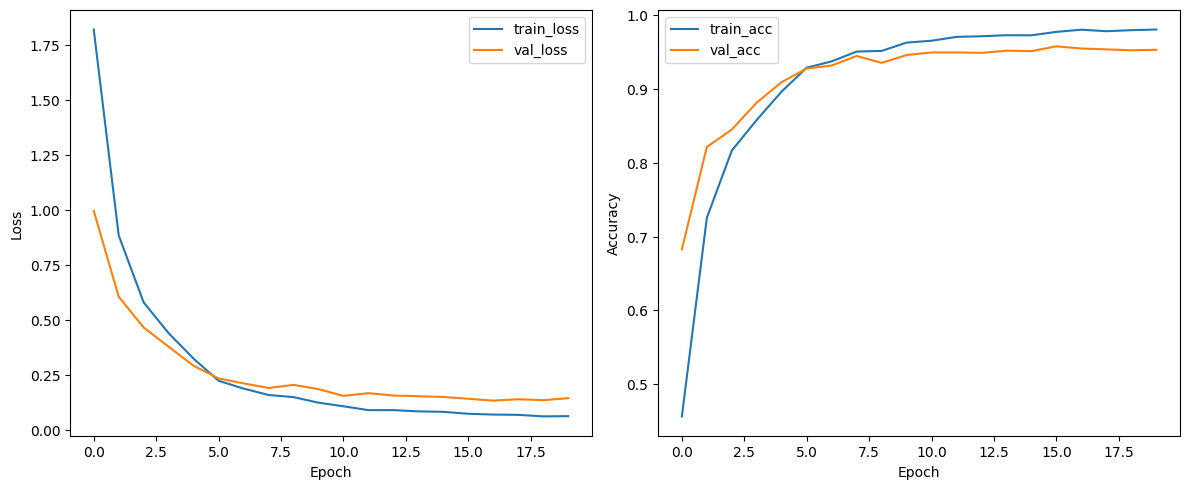

In [ ]:
import pandas as pd
import gc

# create instance of BrainTumorDataModule class
data_module = BrainTumorDataModule(
    data_dir=str(dataset_path),
    batch_size=32,
)

data_module.setup()

models_list = ["MobileNetV2","ResNet50","EfficientNetB0"] # models that will be trained

trained_models = {} # stores the best trained version of each model
model_information = [] # stores the checkpoint path and log directory for each model

for name in models_list:
    print(f"\n>>>> Training {name} <<<<")

    model = BrainTumorLightningModule(model_name=name,num_classes=data_module.num_classes,lr=3e-4,dropout=0.2,weight_decay=1e-4,fine_tune=True) # creates the model using the selected best hyperparameters

    trainer = make_trainer(experiment_name=name,max_epochs=25) # creates the trainer and allows a maximum of 25 epochs

    trainer.fit(model,datamodule=data_module) # trains the model using the training data and checks it using the validation data

    best_checkpoint_path = trainer.checkpoint_callback.best_model_path # gets the path of the model with the lowest validation loss
    best_log_dir = trainer.logger.log_dir # gets the folder containing the training and validation results

    print("Best checkpoint:",best_checkpoint_path)

    best_model = BrainTumorLightningModule.load_from_checkpoint(best_checkpoint_path,map_location="cpu") # loads the best saved version of the trained model

    best_model.eval() # changes the model to evaluation mode

    trained_models[name] = best_model # stores the model so it can be tested and used for ensemble learning

    model_information.append({
        "Model": name,
        "Checkpoint": best_checkpoint_path,
        "Log Directory": best_log_dir}) # stores information about the trained model

    plot_training_curves(best_log_dir) # displays the training and validation accuracy and loss graphs

    del model
    del trainer

    gc.collect() # removes unused objects from memory

    if torch.cuda.is_available():
        torch.cuda.empty_cache() # clears unused GPU memory before training the next model

**Test Models Section**

In [ ]:
individual_results = [] # stores the test results for each trained model

for name,model in trained_models.items():
    print(f"\n>>>> Testing {name} <<<<")

    test_trainer = pl.Trainer(accelerator="auto",devices=1,logger=False) # creates a trainer only for testing

    test_results = test_trainer.test(model,datamodule=data_module)[0] # tests the model using the test dataset and returns the results

    result = {
        "Model": name,
        "Test Accuracy": test_results["test_accuracy"] * 100,
        "Test Precision": test_results["test_precision"] * 100,
        "Test Recall": test_results["test_recall"] * 100,
        "Test F1 Score": test_results["test_f1"] * 100} # stores the model test results as percentages

    individual_results.append(result) # adds the current model results to the list

    print(f"Test Accuracy: {result['Test Accuracy']:.2f}%")
    print(f"Test Precision: {result['Test Precision']:.2f}%")
    print(f"Test Recall: {result['Test Recall']:.2f}%")
    print(f"Test F1 Score: {result['Test F1 Score']:.2f}%")

individual_results_df = pd.DataFrame(individual_results) # converts the model results into a table

display(individual_results_df) # displays the final results table

individual_results_df.to_csv("individual_model_results.csv",index=False) # saves the results table as a CSV file


Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53/53 0:00:03 • 0:00:00 17.38it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9592920541763306     │
│          test_f1          │    0.9515367746353149     │
│         test_loss         │    0.13567107915878296    │
│      test_precision       │     0.95821213722229      │
│        test_recall        │    0.9480111002922058     │
└───────────────────────────┴───────────────────────────┘

Test Accuracy: 95.93%
Test Precision: 95.82%
Test Recall: 94.80%
Test F1 Score: 95.15%


,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,MobileNetV2,90.206492,90.674520,88.553476,89.229321
1,ResNet50,94.395280,93.916547,93.256390,93.447387
2,EfficientNetB0,95.929205,95.821214,94.801110,95.153677


**Ensemble**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # uses GPU for prediction if available

test_loader = data_module.test_dataloader() # loads the test images


def get_predictions(model,dataloader):
    model.to(device) # moves the model to the selected device
    model.eval() # changes the model to evaluation mode

    all_probabilities = []
    all_predictions = []
    all_labels = []

    with torch.no_grad(): # disables gradients because the model is only making predictions
        for images,labels in dataloader:
            images = images.to(device)

            outputs = model(images) # gets the class scores from the model
            probabilities = torch.softmax(outputs,dim=1) # converts the class scores into probabilities
            predictions = probabilities.argmax(dim=1) # selects the class with the highest probability

            all_probabilities.append(probabilities.cpu())
            all_predictions.append(predictions.cpu())
            all_labels.append(labels)

    model.to("cpu") # moves the model back to CPU to free GPU memory

    return torch.cat(all_probabilities),torch.cat(all_predictions),torch.cat(all_labels)


mobilenet_probs,mobilenet_predictions,labels = get_predictions(trained_models["MobileNetV2"],test_loader) # gets MobileNetV2 probabilities and predictions

resnet_probs,resnet_predictions,_ = get_predictions(trained_models["ResNet50"],test_loader) # gets ResNet50 probabilities and predictions

efficientnet_probs,efficientnet_predictions,_ = get_predictions(trained_models["EfficientNetB0"],test_loader) # gets EfficientNet-B0 probabilities and predictions


# Soft Voting

soft_voting_probs = (mobilenet_probs + resnet_probs + efficientnet_probs) / 3 # averages the probabilities from the three models

soft_voting_predictions = soft_voting_probs.argmax(dim=1) # selects the class with the highest average probability

soft_voting_accuracy = (soft_voting_predictions == labels).float().mean() # calculates soft voting accuracy

print(f"Soft Voting Accuracy: {soft_voting_accuracy.item() * 100:.2f}%")


# Hard Voting

all_model_predictions = torch.stack([mobilenet_predictions,resnet_predictions,efficientnet_predictions]) # combines the predicted classes from the three models

hard_voting_predictions = torch.mode(all_model_predictions,dim=0).values # selects the class predicted by the majority

hard_voting_accuracy = (hard_voting_predictions == labels).float().mean() # calculates hard voting accuracy

print(f"Hard Voting Accuracy: {hard_voting_accuracy.item() * 100:.2f}%")


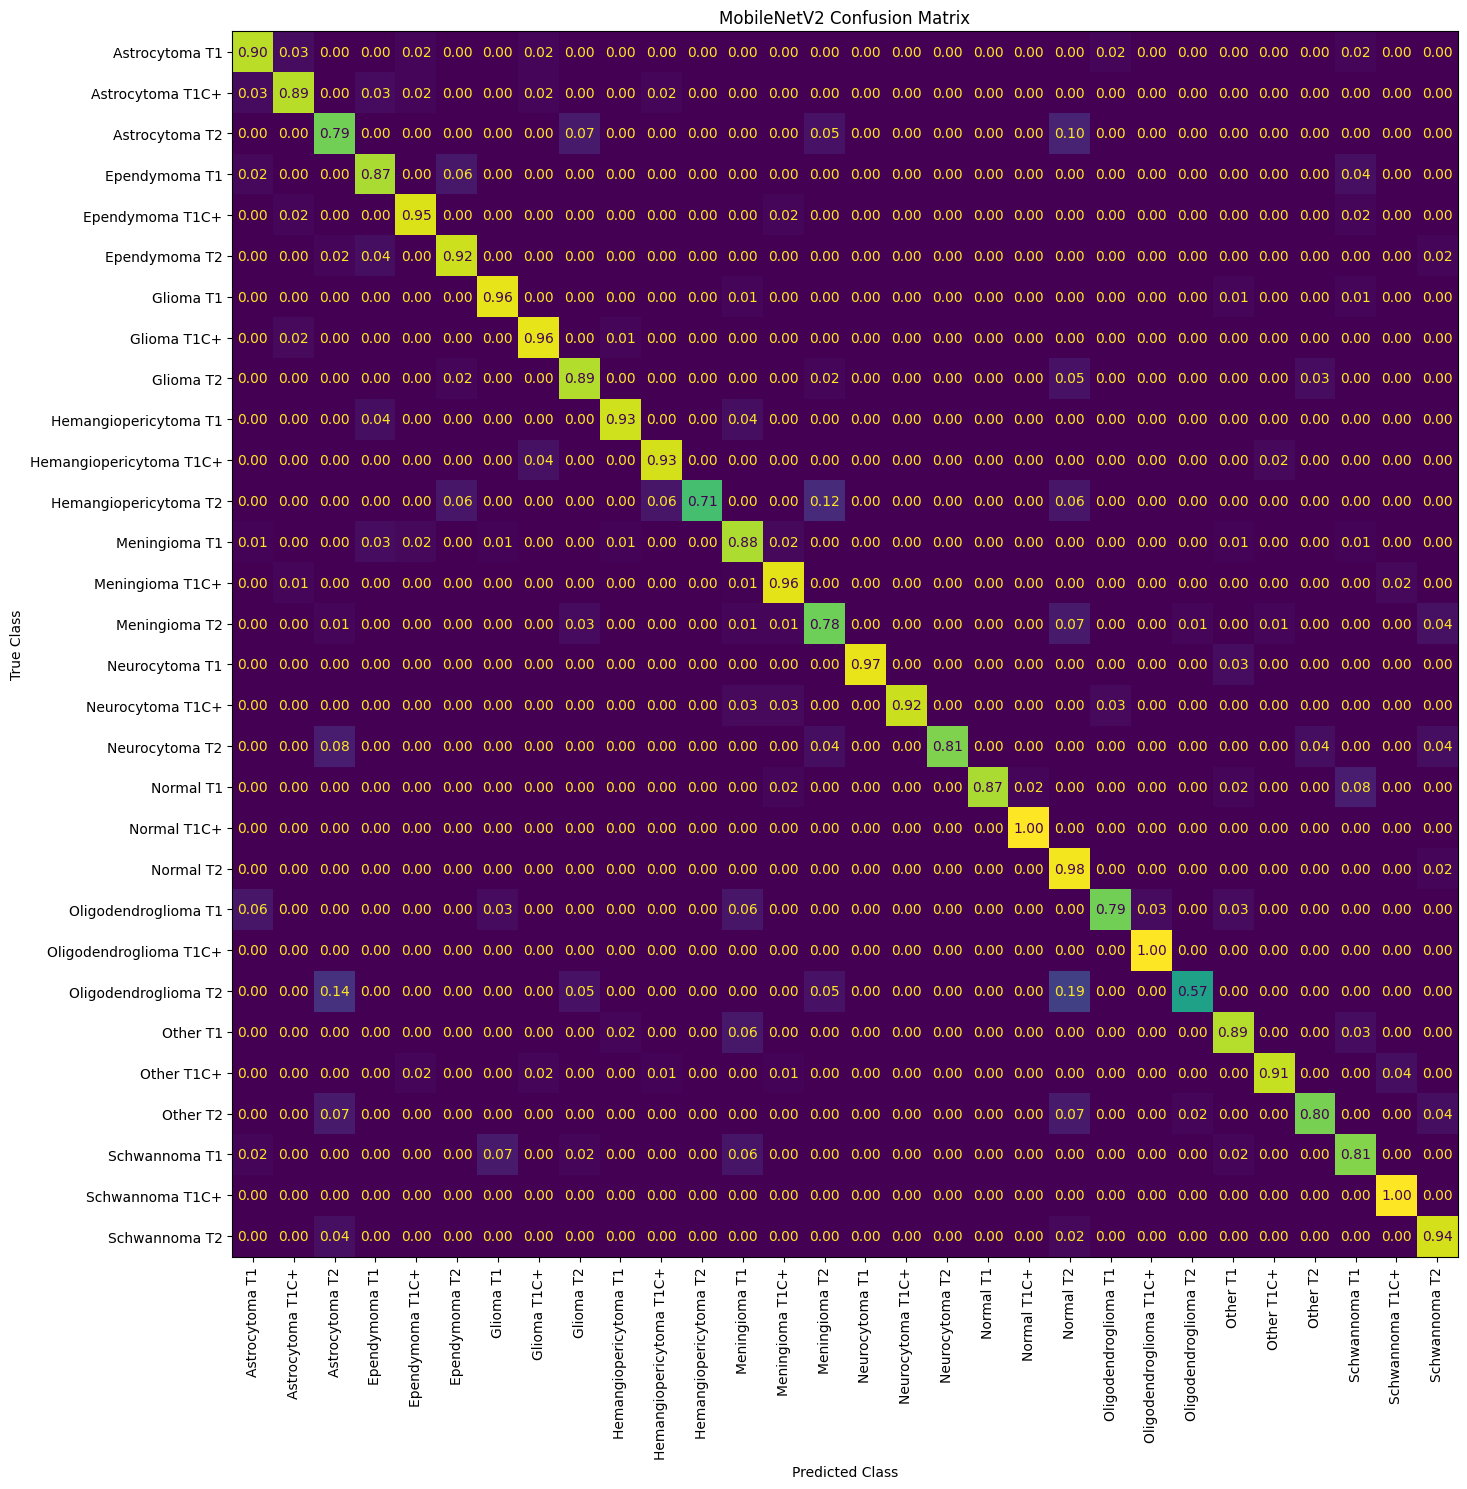

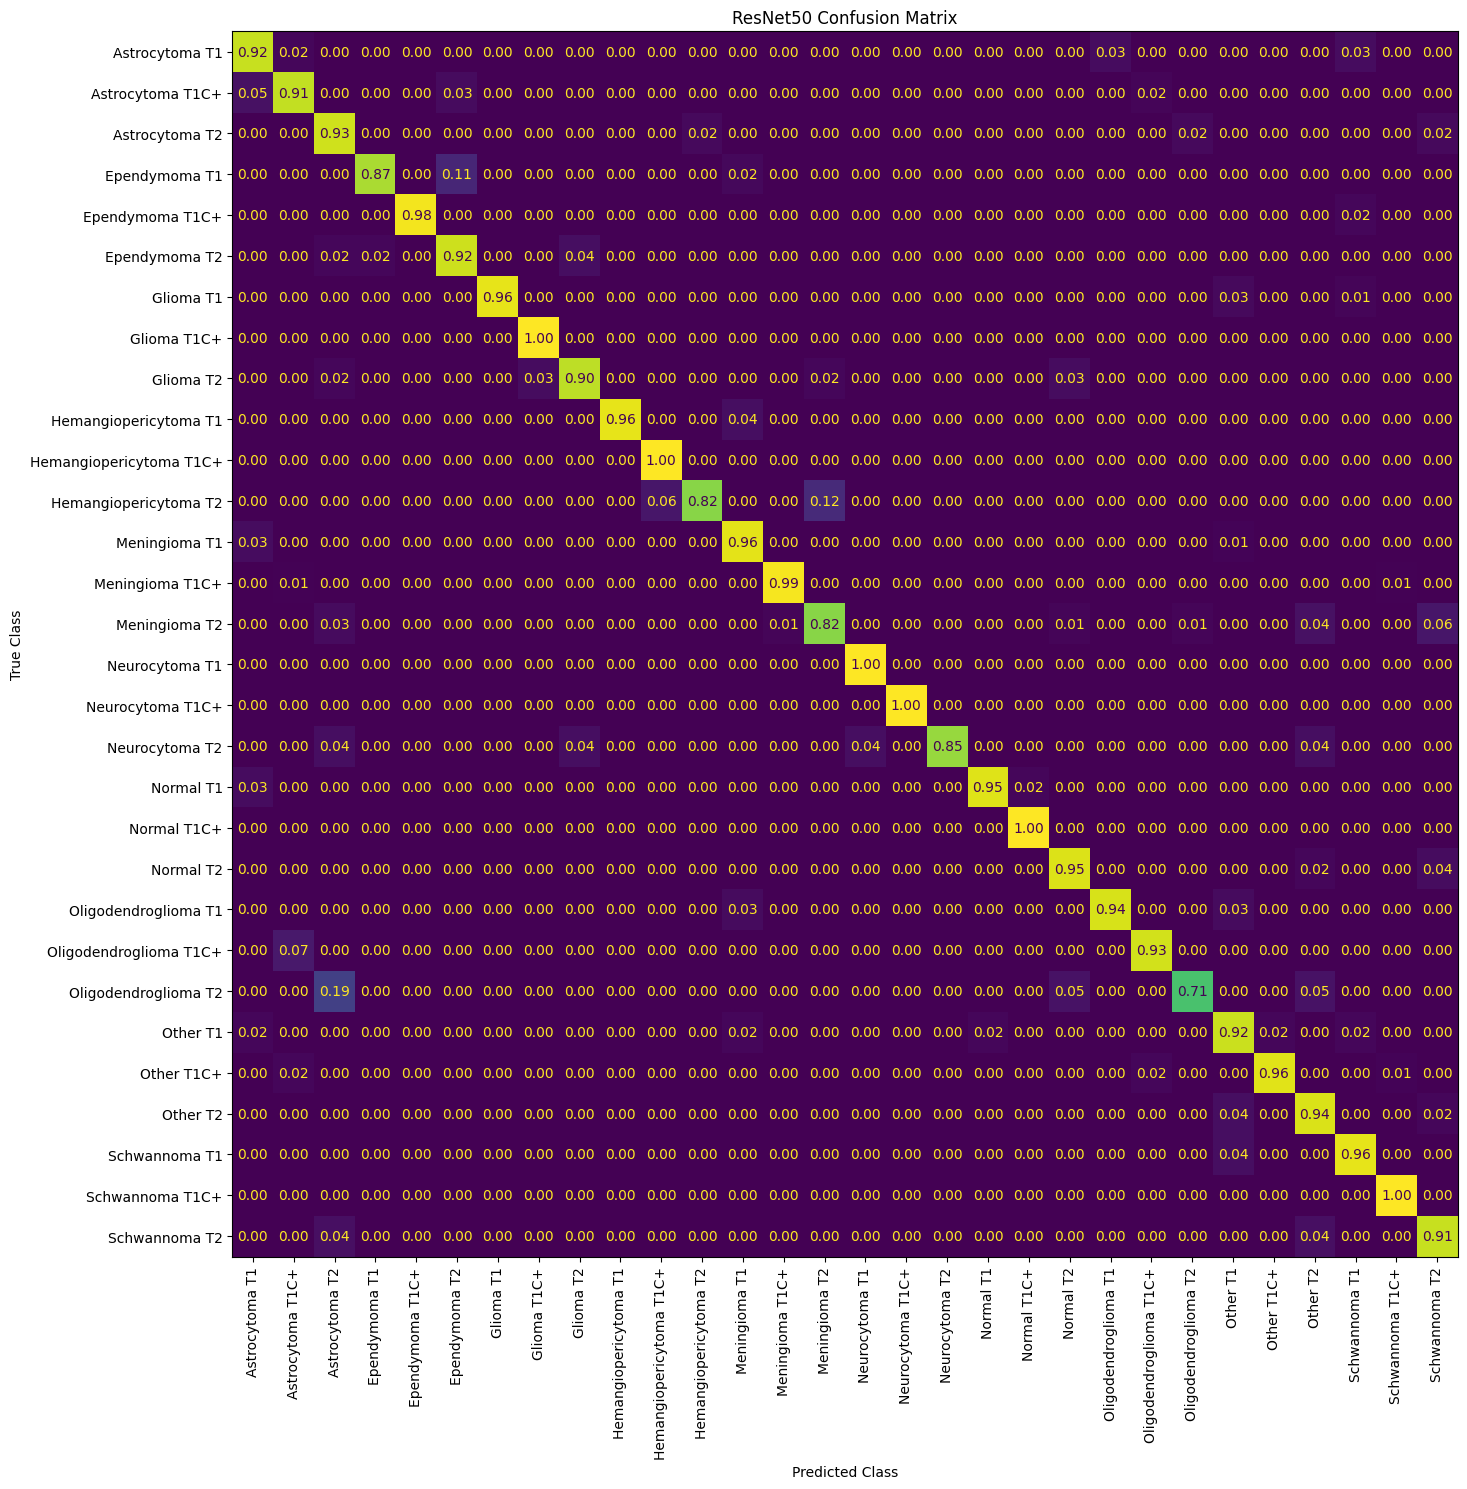

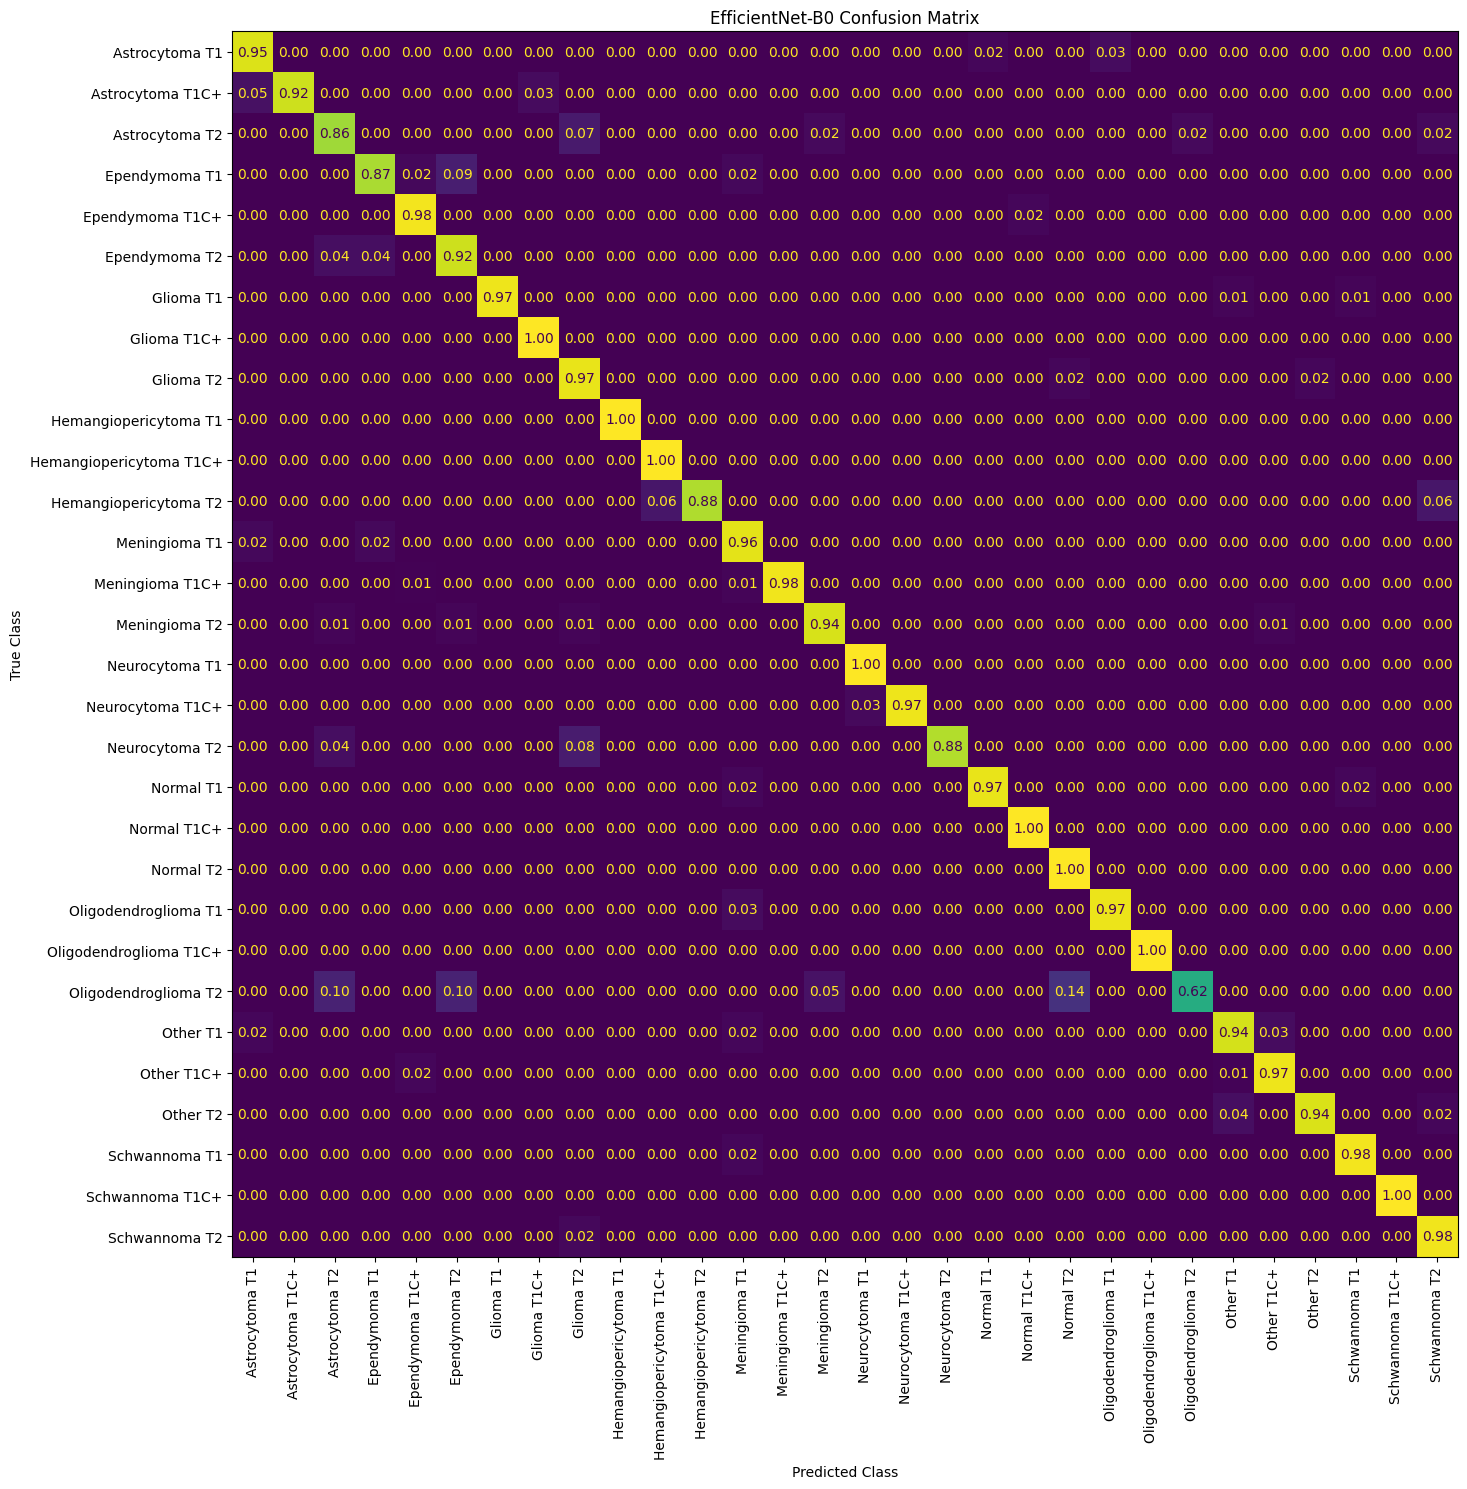

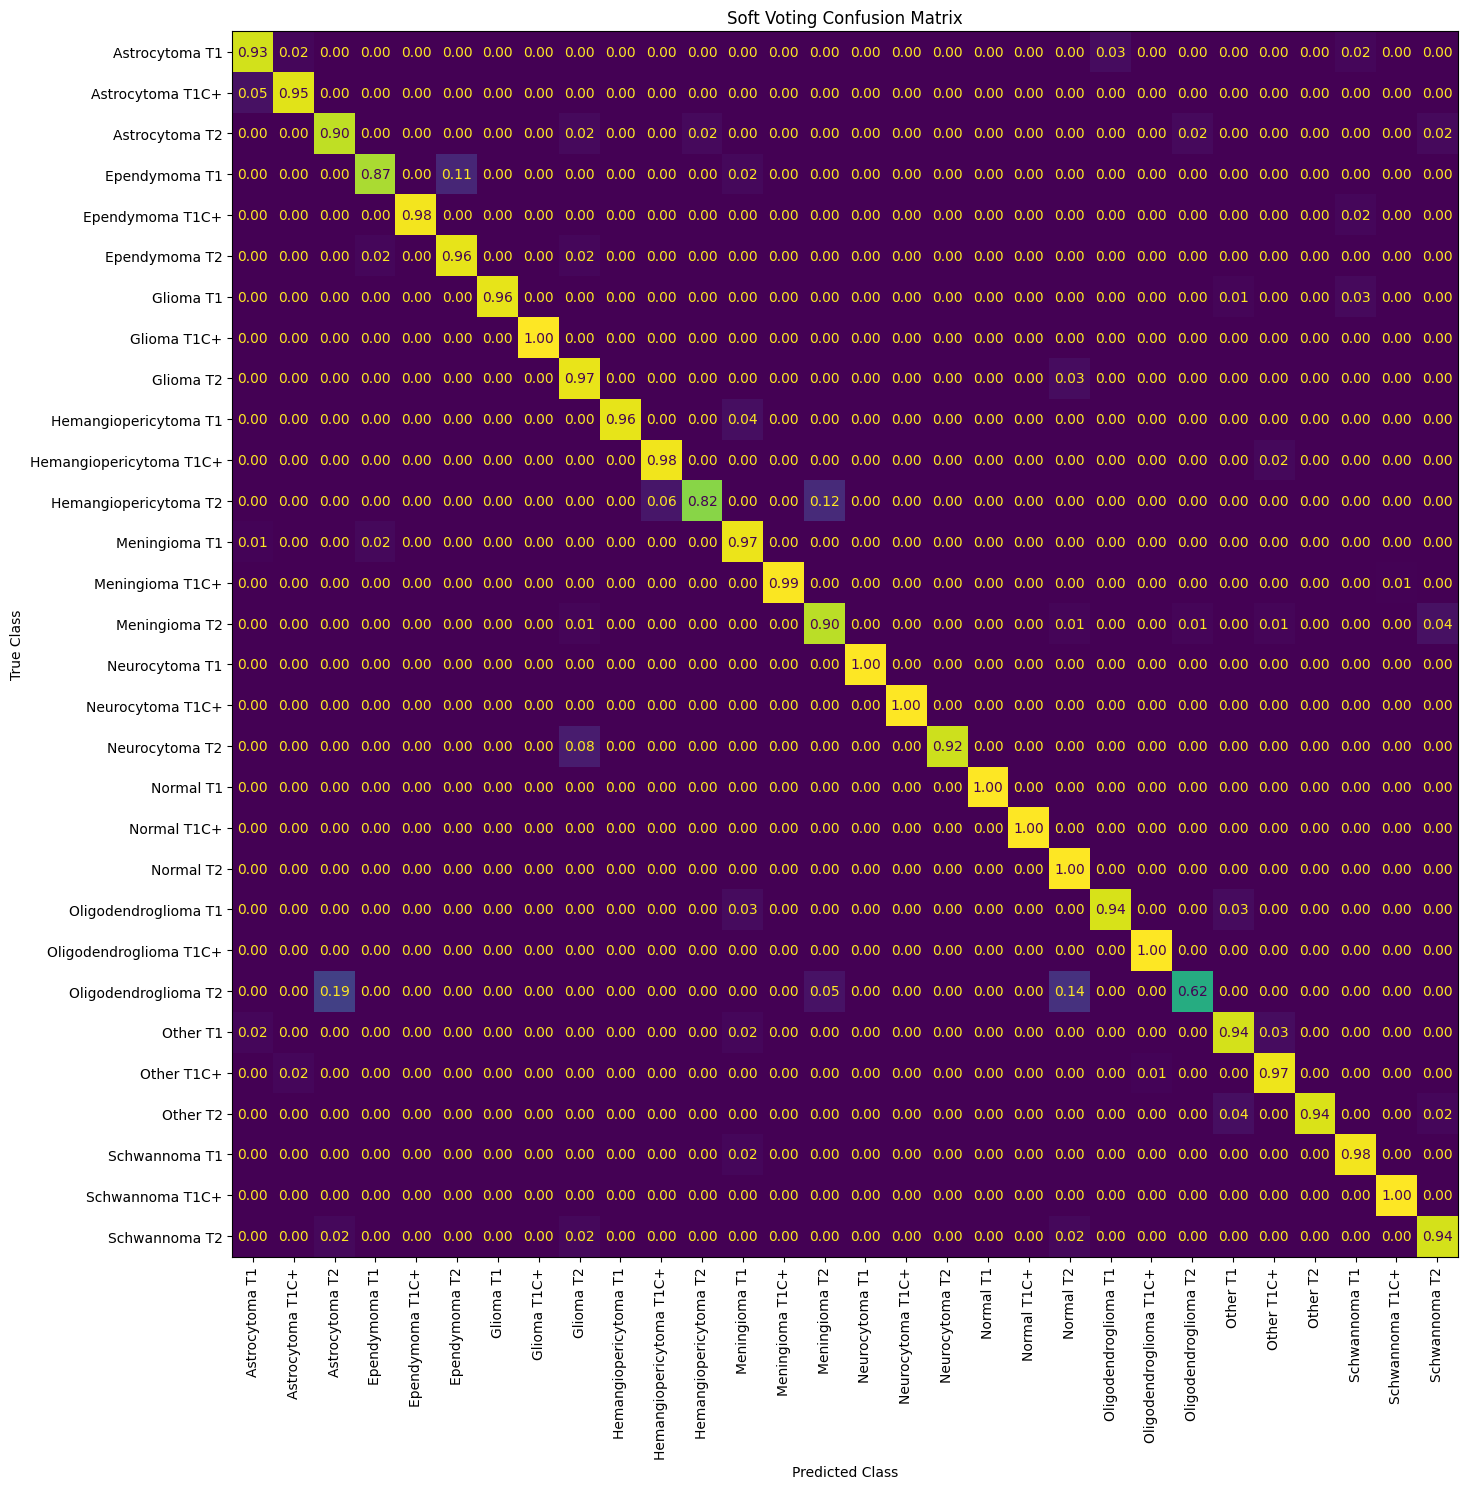

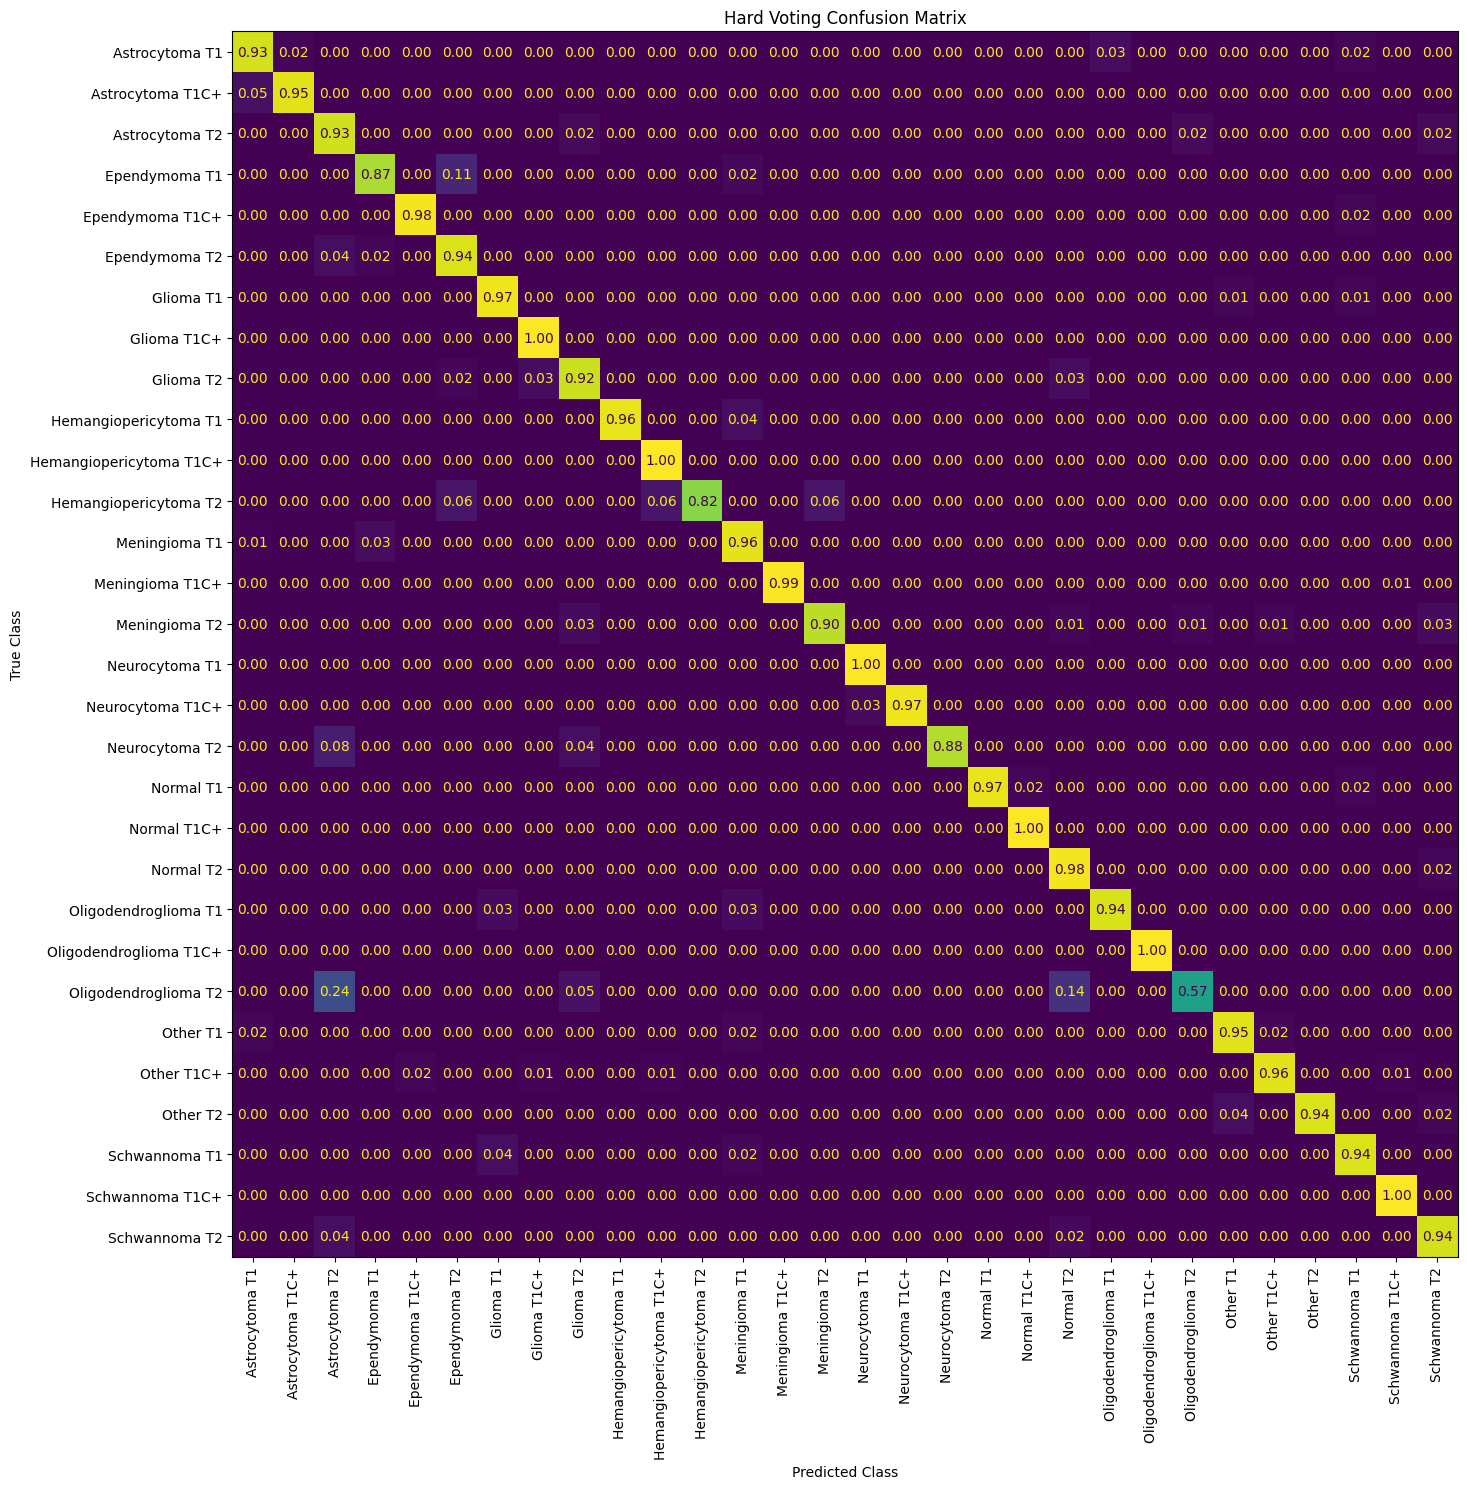

,Model,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2,90.206492,90.674520,88.553476,89.229321
1,ResNet50,94.395280,93.916547,93.256390,93.447387
2,EfficientNetB0,95.929205,95.821214,94.801110,95.153677
3,Soft Voting,96.047199,95.656669,94.710267,95.064787
4,Hard Voting,95.398229,95.102905,93.973886,94.348009


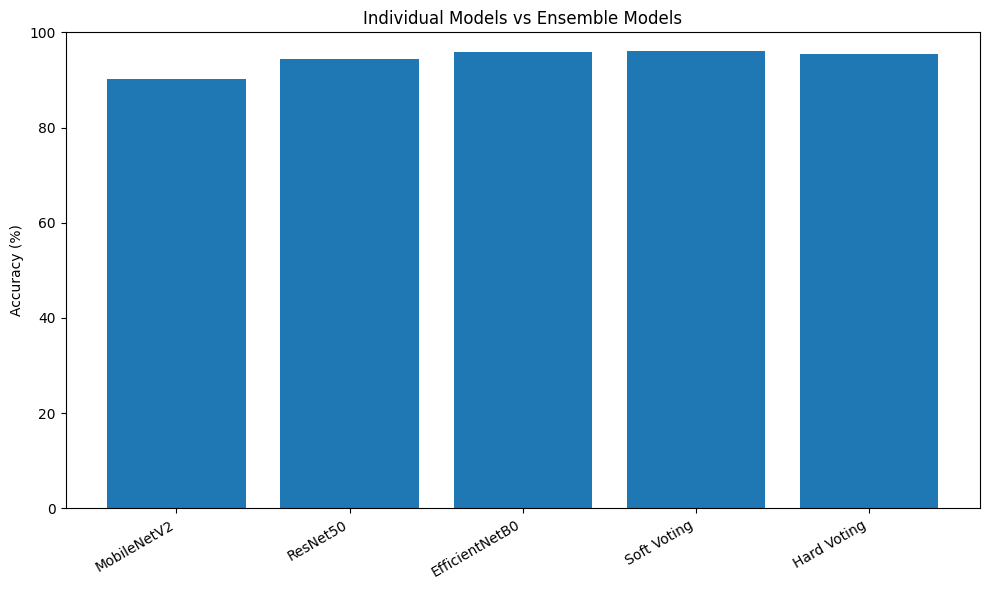

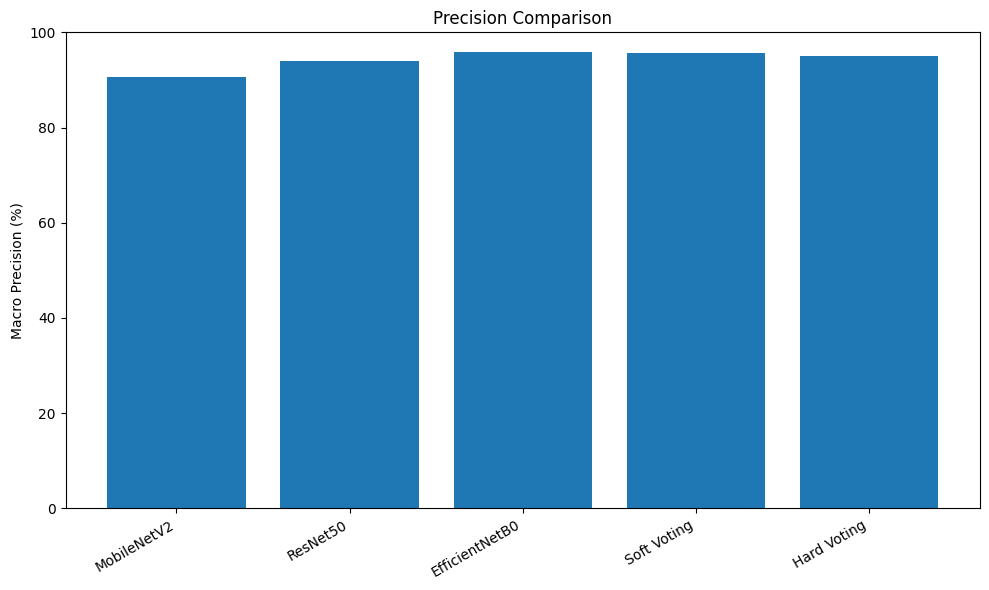

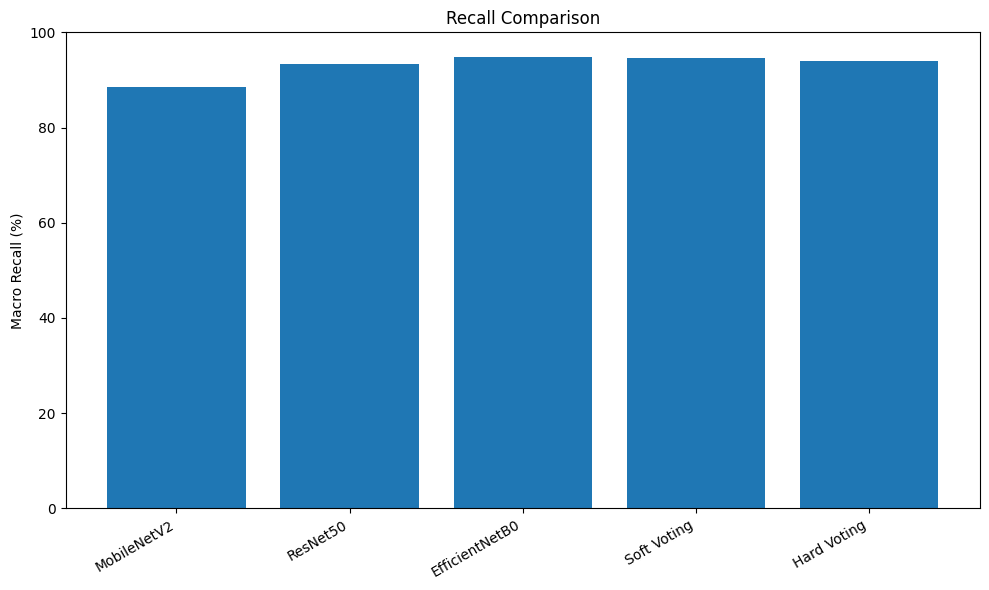

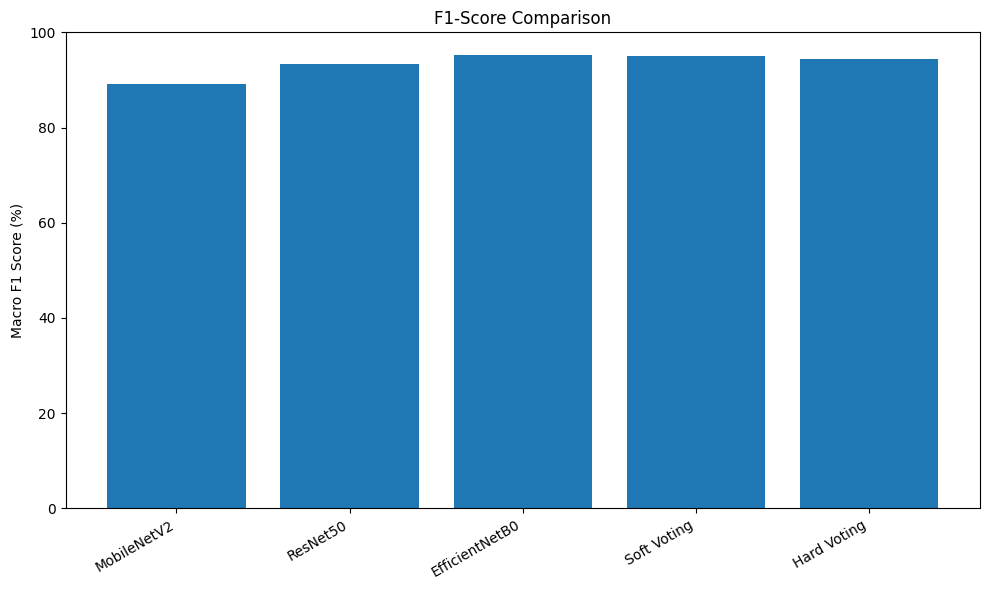

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mobilenet_confusion_matrix = confusion_matrix(labels.numpy(), mobilenet_predictions.numpy(), normalize="true") # creates a normalized confusion matrix for MobileNetV2

plt.figure(figsize=(15,15))
mobilenet_display = ConfusionMatrixDisplay(confusion_matrix=mobilenet_confusion_matrix, display_labels=data_module.class_names)
mobilenet_display.plot(xticks_rotation=90, values_format=".2f", ax=plt.gca(), colorbar=False)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


resnet_confusion_matrix = confusion_matrix(labels.numpy(), resnet_predictions.numpy(), normalize="true") # creates a normalized confusion matrix for ResNet50

plt.figure(figsize=(15,15))
resnet_display = ConfusionMatrixDisplay(confusion_matrix=resnet_confusion_matrix, display_labels=data_module.class_names)
resnet_display.plot(xticks_rotation=90, values_format=".2f", ax=plt.gca(), colorbar=False)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


efficientnet_confusion_matrix = confusion_matrix(labels.numpy(), efficientnet_predictions.numpy(), normalize="true") # creates a normalized confusion matrix for EfficientNet-B0

plt.figure(figsize=(15,15))
efficientnet_display = ConfusionMatrixDisplay(confusion_matrix=efficientnet_confusion_matrix, display_labels=data_module.class_names)
efficientnet_display.plot(xticks_rotation=90, values_format=".2f", ax=plt.gca(), colorbar=False)
plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


soft_confusion_matrix = confusion_matrix(labels.numpy(), soft_voting_predictions.numpy(), normalize="true") # creates a normalized confusion matrix for soft voting

plt.figure(figsize=(15,15))
soft_display = ConfusionMatrixDisplay(confusion_matrix=soft_confusion_matrix, display_labels=data_module.class_names)
soft_display.plot(xticks_rotation=90, values_format=".2f", ax=plt.gca(), colorbar=False)
plt.title("Soft Voting Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


hard_confusion_matrix = confusion_matrix(labels.numpy(), hard_voting_predictions.numpy(), normalize="true") # creates a normalized confusion matrix for hard voting

plt.figure(figsize=(15,15))
hard_display = ConfusionMatrixDisplay(confusion_matrix=hard_confusion_matrix, display_labels=data_module.class_names)
hard_display.plot(xticks_rotation=90, values_format=".2f", ax=plt.gca(), colorbar=False)
plt.title("Hard Voting Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


# calculates macro precision, recall, and F1 score for soft voting
soft_voting_precision = precision_score(labels.numpy(), soft_voting_predictions.numpy(), average="macro", zero_division=0) * 100
soft_voting_recall = recall_score(labels.numpy(), soft_voting_predictions.numpy(), average="macro", zero_division=0) * 100
soft_voting_f1 = f1_score(labels.numpy(), soft_voting_predictions.numpy(), average="macro", zero_division=0) * 100

# calculates macro precision, recall, and F1 score for hard voting
hard_voting_precision = precision_score(labels.numpy(), hard_voting_predictions.numpy(), average="macro", zero_division=0) * 100
hard_voting_recall = recall_score(labels.numpy(), hard_voting_predictions.numpy(), average="macro", zero_division=0) * 100
hard_voting_f1 = f1_score(labels.numpy(), hard_voting_predictions.numpy(), average="macro", zero_division=0) * 100


ensemble_results = [
    {
        "Model": "Soft Voting",
        "Accuracy": soft_voting_accuracy.item() * 100,
        "Precision": soft_voting_precision,
        "Recall": soft_voting_recall,
        "F1 Score": soft_voting_f1
    },
    {
        "Model": "Hard Voting",
        "Accuracy": hard_voting_accuracy.item() * 100,
        "Precision": hard_voting_precision,
        "Recall": hard_voting_recall,
        "F1 Score": hard_voting_f1
    }
] # stores all soft and hard voting results


individual_graph_results = individual_results_df.rename(columns={
    "Test Accuracy": "Accuracy",
    "Test Precision": "Precision",
    "Test Recall": "Recall",
    "Test F1 Score": "F1 Score"
}) # changes the individual model column names to match the ensemble results

individual_graph_results = individual_graph_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
] # keeps the evaluation metrics needed for comparison

ensemble_results_df = pd.DataFrame(ensemble_results) # converts the ensemble results into a table

final_results_df = pd.concat(
    [individual_graph_results, ensemble_results_df],
    ignore_index=True
) # combines individual and ensemble results

display(final_results_df) # displays all individual and ensemble results


plt.figure(figsize=(10,6))
plt.bar(final_results_df["Model"], final_results_df["Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Individual Models vs Ensemble Models")
plt.ylim(0,100)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
plt.bar(final_results_df["Model"], final_results_df["Precision"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro Precision (%)")
plt.title("Precision Comparison")
plt.ylim(0,100)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
plt.bar(final_results_df["Model"], final_results_df["Recall"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro Recall (%)")
plt.title("Recall Comparison")
plt.ylim(0,100)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
plt.bar(final_results_df["Model"], final_results_df["F1 Score"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro F1 Score (%)")
plt.title("F1-Score Comparison")
plt.ylim(0,100)
plt.tight_layout()
plt.show()

# Ablation Studies


,Configuration,Accuracy,Precision,Recall,F1 Score
0,All Three Models,96.047198,95.656669,94.710267,95.064787
1,Without EfficientNetB0,94.808260,94.667206,93.671871,93.982876
2,Without ResNet50,95.575221,95.475459,94.470524,94.832968
3,Without MobileNetV2,96.342183,95.977485,95.188654,95.453187


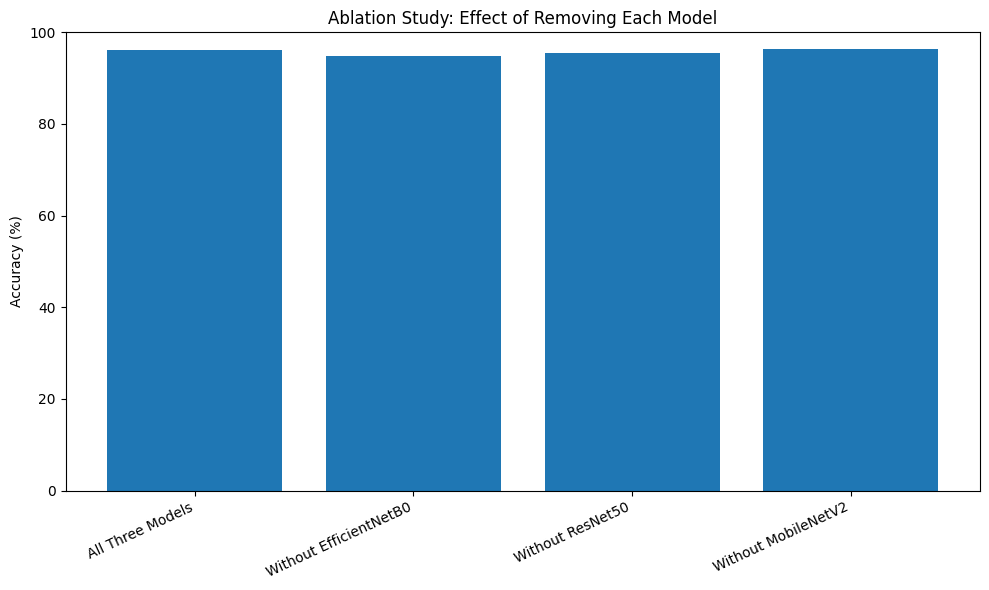

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate_predictions(name, true_labels, predictions):
    """Calculate evaluation metrics for one ablation configuration."""

    true_labels = true_labels.numpy()
    predictions = predictions.numpy()

    return {
        "Configuration": name,
        "Accuracy": accuracy_score(true_labels, predictions) * 100,
        "Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100,
        "Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100,
        "F1 Score": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100
    }


ablation_results = []

# All three models

all_three_probs = (
    mobilenet_probs +
    resnet_probs +
    efficientnet_probs
) / 3

all_three_predictions = all_three_probs.argmax(dim=1)

ablation_results.append(
    evaluate_predictions(
        "All Three Models",
        labels,
        all_three_predictions
    )
)

# MobileNetV2 + ResNet50

mobilenet_resnet_probs = (
    mobilenet_probs +
    resnet_probs
) / 2

mobilenet_resnet_predictions = mobilenet_resnet_probs.argmax(dim=1)

ablation_results.append(
    evaluate_predictions(
        "Without EfficientNetB0",
        labels,
        mobilenet_resnet_predictions
    )
)

# MobileNetV2 + EfficientNetB0

mobilenet_efficientnet_probs = (
    mobilenet_probs +
    efficientnet_probs
) / 2

mobilenet_efficientnet_predictions = (
    mobilenet_efficientnet_probs.argmax(dim=1)
)

ablation_results.append(
    evaluate_predictions(
        "Without ResNet50",
        labels,
        mobilenet_efficientnet_predictions
    )
)

# ResNet50 + EfficientNetB0

resnet_efficientnet_probs = (
    resnet_probs +
    efficientnet_probs
) / 2

resnet_efficientnet_predictions = (
    resnet_efficientnet_probs.argmax(dim=1)
)

ablation_results.append(
    evaluate_predictions(
        "Without MobileNetV2",
        labels,
        resnet_efficientnet_predictions
    )
)

ablation_results_df = pd.DataFrame(ablation_results)

display(ablation_results_df)

ablation_results_df.to_csv(
    "ablation_study_results.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    ablation_results_df["Configuration"],
    ablation_results_df["Accuracy"]
)

plt.xticks(rotation=25, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Ablation Study: Effect of Removing Each Model")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()